In [1]:
from matplotlib import pyplot as plt
import re
import numpy as np

In [6]:
with open('/lustre/scratch127/qpg/jc59/qaoa_depth_width/results.txt', 'r') as f:
    results = f.readlines()

In [7]:
results

['21, 3, 3, 3754, 1249, 2268, 232,\n',
 '35, 5, 3, 8824, 2234, 6044, 364,\n',
 '45, 5, 4, 15056, 3485, 10376, 484,\n',
 ' 54, 6, 4, 20683, 4273, 15444, 592,\n',
 ' 161, 7, 11, 155621, 20903, 149340, 1888,\n',
 ' 119, 7, 8, 87724, 15257, 79120, 1360,\n',
 ' 153, 9, 8, 122735, 18649, 132748, 1768,\n',
 ' 126, 6, 10, 104801, 15420, 90860, 1468,\n',
 ' 171, 9, 9, 154555, 22499, 166028, 1972,\n',
 ' 65, 5, 6, 31149, 6178, 22316, 712,\n',
 ' 65, 5, 6, 31002, 6116, 22312, 712,\n',
 ' 75, 5, 7, 41033, 7391, 30840, 844,\n',
 ' 21, 3, 3, 3488, 1190, 2132, 220,\n',
 ' 33, 3, 5, 9205, 2446, 5900, 376,\n',
 ' 65, 5, 6, 30735, 5810, 22480, 724]\n']

In [8]:
res = np.array(sorted([
    [int(m) for m in re.findall(r'[0-9]+', x)] for x in results 
], key=lambda e: e[0]
))

In [92]:
# keep_rows = [0]
# for i in range(1, res.shape[0]):
#     if not res[i, 0] == res[i-1, 0]:
#         keep_rows.append(i)

# res = res[keep_rows, :]

In [9]:
res

array([[    21,      3,      3,   3754,   1249,   2268,    232],
       [    21,      3,      3,   3488,   1190,   2132,    220],
       [    33,      3,      5,   9205,   2446,   5900,    376],
       [    35,      5,      3,   8824,   2234,   6044,    364],
       [    45,      5,      4,  15056,   3485,  10376,    484],
       [    54,      6,      4,  20683,   4273,  15444,    592],
       [    65,      5,      6,  31149,   6178,  22316,    712],
       [    65,      5,      6,  31002,   6116,  22312,    712],
       [    65,      5,      6,  30735,   5810,  22480,    724],
       [    75,      5,      7,  41033,   7391,  30840,    844],
       [   119,      7,      8,  87724,  15257,  79120,   1360],
       [   126,      6,     10, 104801,  15420,  90860,   1468],
       [   153,      9,      8, 122735,  18649, 132748,   1768],
       [   161,      7,     11, 155621,  20903, 149340,   1888],
       [   171,      9,      9, 154555,  22499, 166028,   1972]])

In [11]:
res[:,0]

array([ 21,  21,  33,  35,  45,  54,  65,  65,  65,  75, 119, 126, 153,
       161, 171])

In [12]:
res[:, 3]

array([  3754,   3488,   9205,   8824,  15056,  20683,  31149,  31002,
        30735,  41033,  87724, 104801, 122735, 155621, 154555])

In [13]:
grid = np.linspace(res[0, 0], res[-1, 0], 100)
p_depth_pre = np.poly1d(np.polyfit(res[:, 0], res[:, 4], 1))
p_depth_post = np.poly1d(np.polyfit(res[:, 0], res[:, 6], 1))
p_count_pre = np.poly1d(np.polyfit(res[:, 0], res[:, 3], 2))
p_count_post = np.poly1d(np.polyfit(res[:, 0], res[:, 5], 2))

Text(0.5, 1.0, '2-qubit gate depth and count for tangle resolution QAOA')

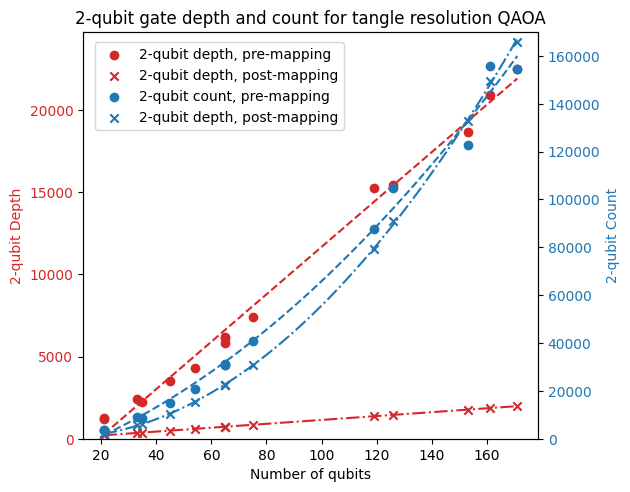

In [14]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.scatter(res[:,0], res[:,4], color=color, label='2-qubit depth, pre-mapping')
ax1.scatter(res[:,0], res[:,6], color=color, marker='x', label='2-qubit depth, post-mapping')


ax1.plot(grid, p_depth_pre(grid), color=color, linestyle='--')

ax1.plot(grid, p_depth_post(grid), color=color, linestyle='-.')


ax1.set_xlabel('Number of qubits')
ax1.set_ylabel('2-qubit Depth', color=color)
ax1.set_ylim(0, res[-1,4] * 1.1)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.scatter(res[:,0], res[:,3], color=color, label='2-qubit count, pre-mapping')
ax2.scatter(res[:,0], res[:,5], marker='x', color=color, label='2-qubit depth, post-mapping')

ax2.plot(grid, p_count_pre(grid), color=color, linestyle='--')

ax2.plot(grid, p_count_post(grid), color=color, linestyle='-.')

ax2.set_ylabel('2-qubit Count', color=color)
ax2.set_ylim(0, res[-1,3] * 1.1)
ax2.tick_params(axis='y', labelcolor=color)


fig.legend(loc=(0.15,0.735))
fig.tight_layout()
ax1.set_title('2-qubit gate depth and count for tangle resolution QAOA')

In [16]:
p_depth_post(127)

np.float64(1462.6790923307692)

In [128]:
p_count_post(770)

np.float64(3508819.0578043004)

In [109]:
from brokenaxes import brokenaxes

[[<matplotlib.lines.Line2D at 0x7fccaedb7280>],

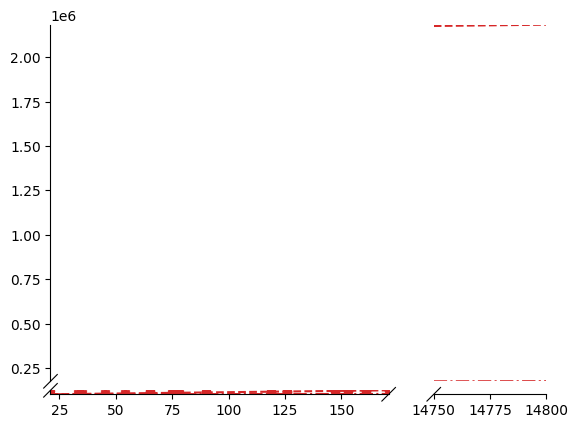

In [117]:
high_grid = np.linspace(14750, 14800, 100)
fig = plt.figure()
bax = brokenaxes(
    xlims=((res[0,0], res[-1,0]), (high_grid[0], high_grid[-1])), 
    ylims=((1, p_depth_pre(grid[-1])), (p_depth_post(high_grid[0]), p_depth_pre(high_grid[-1]))), 
    hspace=.05,
)

color = 'tab:red'

bax.scatter(res[:,0], res[:,4], color=color, label='2-qubit depth, pre-mapping')
bax.scatter(res[:,0], res[:,6], color=color, marker='x', label='2-qubit depth, post-mapping')

bax.plot(grid, p_depth_pre(grid), color=color, linestyle='--')
bax.plot(grid, p_depth_post(grid), color=color, linestyle='-.')

bax.plot(high_grid, p_depth_pre(high_grid), color=color, linestyle='--')
bax.plot(high_grid, p_depth_post(high_grid), color=color, linestyle='-.')


# # hide the spines between ax and ax2
# ax11.spines.bottom.set_visible(False)
# ax12.spines.top.set_visible(False)
# ax11.xaxis.tick_top()
# ax11.tick_params(labeltop=False)  # don't put tick labels at the top
# ax12.xaxis.tick_bottom()